In [1]:
# -*- coding: utf-8 -*-
"""OCR_Three_Way_Comparison.ipynb

Automatically generated in Colab.

This notebook compares Tesseract, EasyOCR, and PaddleOCR on multiple variations of a single image.
"""

# Uninstall any conflicting packages
!pip uninstall -y langchain langchain-community paddlepaddle paddlepaddle-gpu paddleocr paddlex opencv-python opencv-contrib-python

# Install langchain 0.0.345 (required for paddlex imports)
!pip install langchain==0.0.345

# Install Tesseract and pytesseract
!sudo apt update
!sudo apt install -y tesseract-ocr
!pip install pytesseract

# Install EasyOCR
!pip install easyocr

# Install paddlepaddle (CPU version) and paddleocr
!pip install paddlepaddle==2.6.2
!pip install paddleocr==2.9.1

# Force-reinstall langchain to ensure correct version
!pip install langchain==0.0.345 --force-reinstall

# Common image processing libraries
!pip install opencv-python-headless pillow

# Set environment variable to skip model source check for PaddleOCR
import os
os.environ['PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK'] = 'True'

print("\n✅ All libraries installed. PLEASE RESTART THE RUNTIME NOW (Runtime → Restart runtime).")

Found existing installation: langchain 0.0.345
Uninstalling langchain-0.0.345:
  Successfully uninstalled langchain-0.0.345
  Using cached langchain-0.0.345-py3-none-any.whl.metadata (16 kB)
Using cached langchain-0.0.345-py3-none-any.whl (2.0 MB)
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
118 packages can be upgraded. Run 'apt list --upgradable' to see 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: opt-einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to de

  Using cached langchain-0.0.345-py3-none-any.whl.metadata (16 kB)
  Using cached anyio-3.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached langchain_core-0.0.13-py3-none-any.whl.metadata (978 bytes)
  Using cached langsmith-0.0.92-py3-none-any.whl.metadata (9.9 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.7 MB/s eta 0:00:00
  Using cached tenacity-8.5.0-py3-none-any.whl.metadata (1.2 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 7.2 MB/s eta 0:00:00
  Using cached marshmallow-3.26.2-py3-none-any.whl.metadata (7.3 kB)
  Using cached typing_inspect-0.9.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
Using cached langchain-0.0.345-py3-none-any.whl (2.


✅ All libraries installed. PLEASE RESTART THE RUNTIME NOW (Runtime → Restart runtime).


# Imports (Run after restart)

In [1]:
import pytesseract
import easyocr
from paddleocr import PaddleOCR
import numpy as np
from PIL import Image, ImageFilter, ImageOps, ImageEnhance
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files
from IPython.display import display, HTML
import os
import re

# Set Tesseract path (default in Colab)
pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

print("✅ All modules imported.")

✅ All modules imported.


# Initialize OCR Readers

In [2]:
# Tesseract is called per image, no persistent reader.

# EasyOCR reader (English)
easy_reader = easyocr.Reader(['en'])

# PaddleOCR reader (English)
paddle_ocr = PaddleOCR(use_angle_cls=True, lang='en')

print("✅ OCR readers initialized.")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Completedownload https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:17<00:00, 228.34it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:17<00:00, 563.12it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:17<00:00, 120.60it/s]

[2026/03/09 02:44:42] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c

✅ OCR readers initialized.


# Upload Image and Enter Ground Truth

In [6]:
print("📤 Please upload your image (e.g., Text_image.webp):")
uploaded = files.upload()

# Get the uploaded file name
for fn in uploaded.keys():
    image_path = f"/content/{fn}"
    break

print(f"✅ Using image: {image_path}")

# Ask for ground truth text
ground_truth = input("Enter the exact text that appears in the original image (ground truth): ").strip()
print(f"✅ Ground truth: '{ground_truth}'")

📤 Please upload your image (e.g., Text_image.webp):


Saving Text_image.webp to Text_image (2).webp
✅ Using image: /content/Text_image (2).webp
Enter the exact text that appears in the original image (ground truth): Module 3:
✅ Ground truth: 'Module 3:'


# Transformation Functions

In [7]:
def rotate_image(img, angle=5):
    return img.rotate(angle, expand=True, fillcolor=(255,255,255))

def skew_image(img, shear=0.2):
    arr = np.array(img)
    h, w = arr.shape[:2]
    M = np.float32([[1, shear, 0], [0, 1, 0]])
    new_w = int(w + abs(shear) * h)
    sheared = cv2.warpAffine(arr, M, (new_w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(sheared)

def blur_image(img, radius=2):
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def add_noise(img, intensity=25):
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, intensity, arr.shape)
    noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def adjust_brightness(img, factor=1.5):
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(factor)

def adjust_contrast(img, factor=1.5):
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(factor)

def resize_image(img, scale=0.7):
    new_size = (int(img.width * scale), int(img.height * scale))
    return img.resize(new_size, Image.Resampling.LANCZOS)

def invert_colors(img):
    return ImageOps.invert(img.convert('RGB'))

def perspective_warp(img, strength=0.05):
    w, h = img.size
    src = np.float32([[0,0], [w-1,0], [0,h-1], [w-1,h-1]])
    dst = src + strength * np.random.uniform(-h, h, src.shape)
    dst = dst.astype(np.float32)
    matrix = cv2.getPerspectiveTransform(src, dst)
    arr = np.array(img)
    warped = cv2.warpPerspective(arr, matrix, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(warped)

# Load Original and Generate Variations

📸 Original Image:


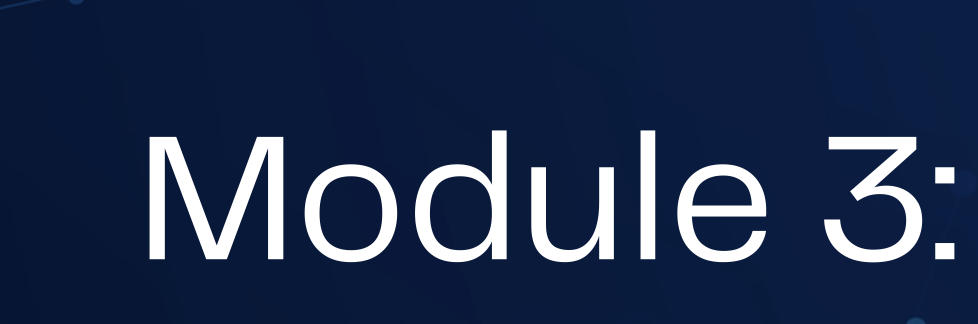

✅ Created 13 image variations.


In [8]:
original_img = Image.open(image_path).convert('RGB')
print("📸 Original Image:")
display(original_img)

variations = []
variations.append((original_img, "Original"))

# Add variations
variations.append((rotate_image(original_img, 5), "Rotated +5°"))
variations.append((rotate_image(original_img, -5), "Rotated -5°"))
variations.append((rotate_image(original_img, 15), "Rotated +15°"))
variations.append((skew_image(original_img, 0.2), "Skewed (shear)"))
variations.append((blur_image(original_img, 2), "Blurred"))
variations.append((add_noise(original_img, 30), "With Noise"))
variations.append((adjust_brightness(original_img, 1.8), "Brighter"))
variations.append((adjust_brightness(original_img, 0.5), "Darker"))
variations.append((adjust_contrast(original_img, 2.0), "High Contrast"))
variations.append((resize_image(original_img, 0.5), "Resized 50%"))
variations.append((invert_colors(original_img), "Inverted Colors"))
variations.append((perspective_warp(original_img, 0.03), "Perspective Warp"))

print(f"✅ Created {len(variations)} image variations.")

# Run OCR on All Variations


--- Processing: Original ---
[2026/03/09 02:50:17] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.2551882266998291
[2026/03/09 02:50:17] ppocr DEBUG: cls num  : 1, elapsed : 0.02469182014465332
[2026/03/09 02:50:17] ppocr DEBUG: rec_res num  : 1, elapsed : 0.10818195343017578


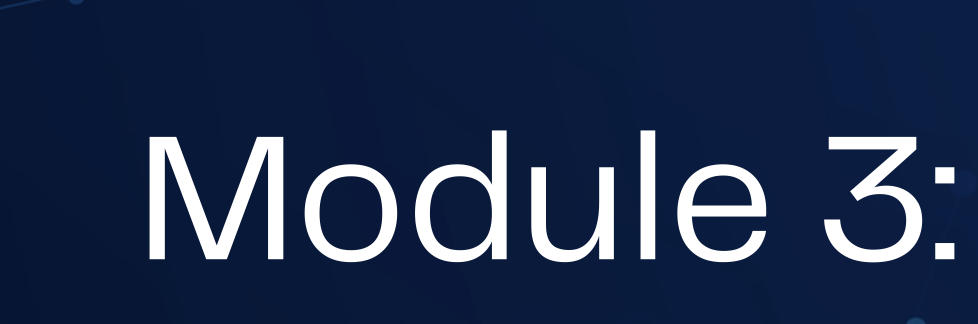

Tesseract : Module 3:
EasyOCR   : Module 3: (conf: 0.85)
PaddleOCR : Module 3: (conf: 1.00)
--------------------------------------------------

--- Processing: Rotated +5° ---
[2026/03/09 02:50:25] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.35777878761291504
[2026/03/09 02:50:25] ppocr DEBUG: cls num  : 1, elapsed : 0.011331796646118164
[2026/03/09 02:50:25] ppocr DEBUG: rec_res num  : 1, elapsed : 0.07509779930114746


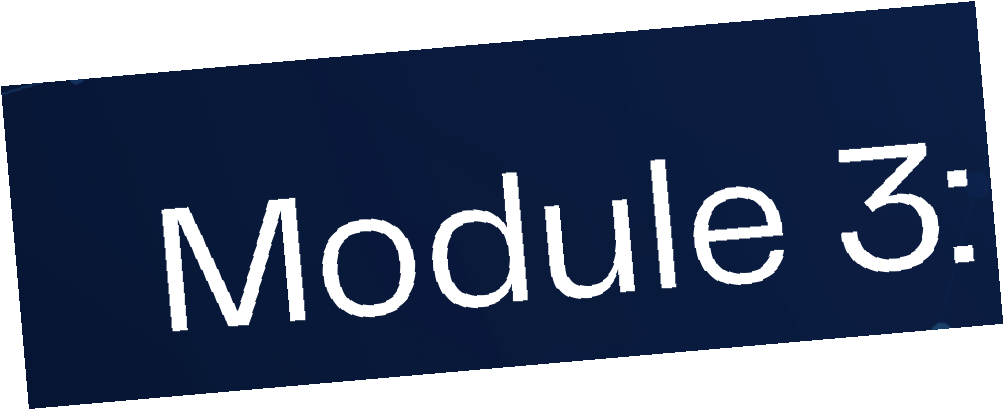

Tesseract : [No text]
EasyOCR   : Module 31 (conf: 0.58)
PaddleOCR : Module 3: (conf: 1.00)
--------------------------------------------------

--- Processing: Rotated -5° ---
[2026/03/09 02:50:31] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.11671781539916992
[2026/03/09 02:50:31] ppocr DEBUG: cls num  : 1, elapsed : 0.01048898696899414
[2026/03/09 02:50:31] ppocr DEBUG: rec_res num  : 1, elapsed : 0.05815243721008301


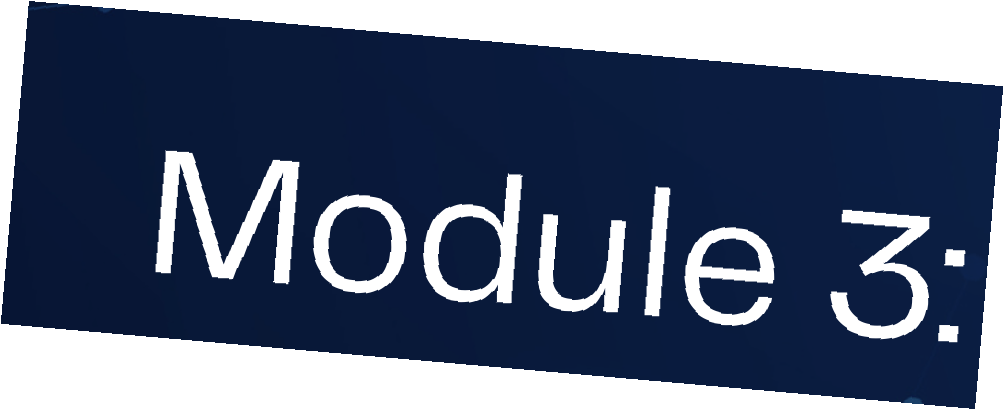

Tesseract : [No text]
EasyOCR   : Module 3: (conf: 0.75)
PaddleOCR : Module 3: (conf: 0.99)
--------------------------------------------------

--- Processing: Rotated +15° ---
[2026/03/09 02:50:42] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.27521777153015137
[2026/03/09 02:50:42] ppocr DEBUG: cls num  : 1, elapsed : 0.01089167594909668
[2026/03/09 02:50:42] ppocr DEBUG: rec_res num  : 1, elapsed : 0.05236172676086426


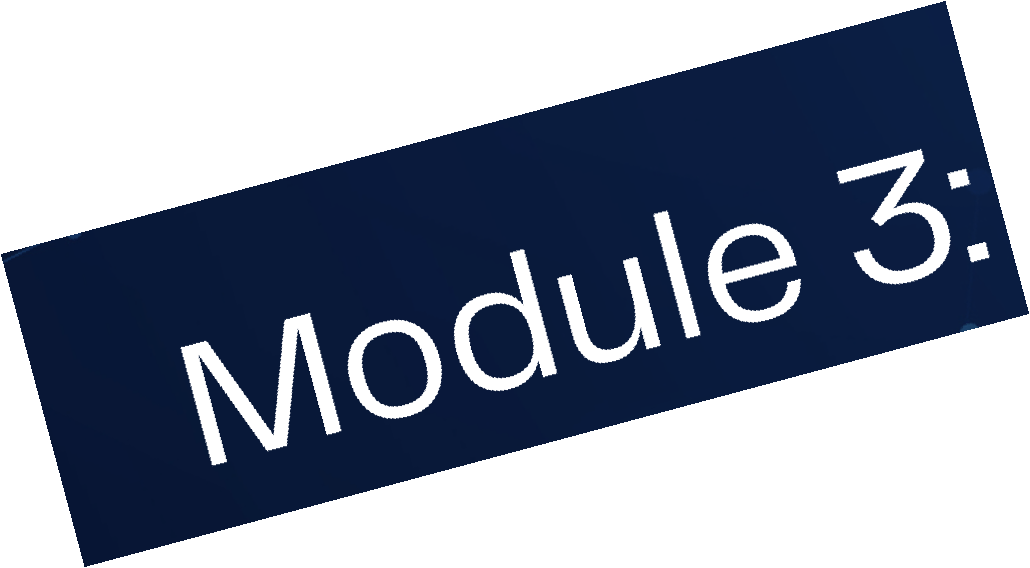

Tesseract : [No text]
EasyOCR   : 3. Module (conf: 0.87)
PaddleOCR : Module 3: (conf: 0.97)
--------------------------------------------------

--- Processing: Skewed (shear) ---
[2026/03/09 02:50:48] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.20122194290161133
[2026/03/09 02:50:48] ppocr DEBUG: cls num  : 1, elapsed : 0.011363744735717773
[2026/03/09 02:50:48] ppocr DEBUG: rec_res num  : 1, elapsed : 0.05158042907714844


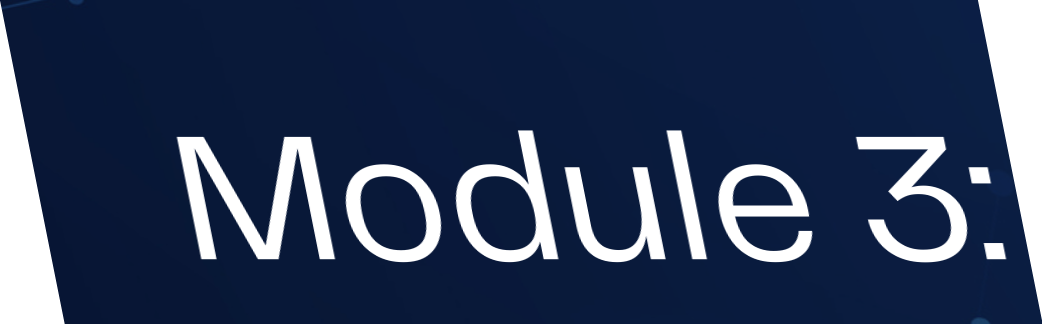

Tesseract : Module a
EasyOCR   : Module 31 (conf: 0.86)
PaddleOCR : Module 3: (conf: 0.96)
--------------------------------------------------

--- Processing: Blurred ---
[2026/03/09 02:50:54] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.09985709190368652
[2026/03/09 02:50:54] ppocr DEBUG: cls num  : 1, elapsed : 0.009560346603393555
[2026/03/09 02:50:54] ppocr DEBUG: rec_res num  : 1, elapsed : 0.053748369216918945


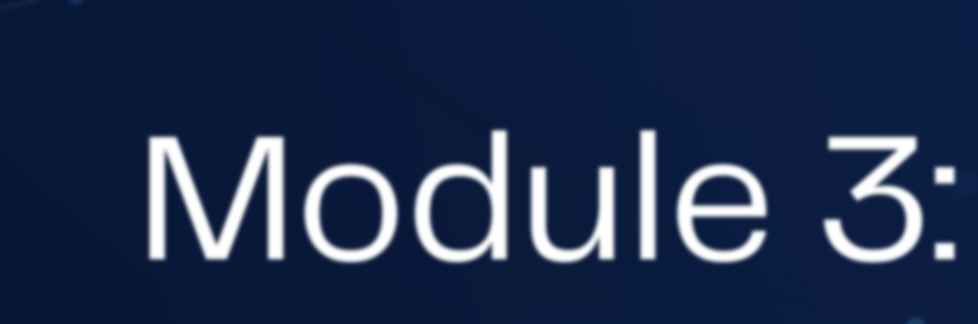

Tesseract : Module 3:
EasyOCR   : Module 3: (conf: 0.95)
PaddleOCR : Module 3: (conf: 1.00)
--------------------------------------------------

--- Processing: With Noise ---
[2026/03/09 02:50:59] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.09498929977416992
[2026/03/09 02:50:59] ppocr DEBUG: cls num  : 1, elapsed : 0.012731552124023438
[2026/03/09 02:50:59] ppocr DEBUG: rec_res num  : 1, elapsed : 0.05119824409484863


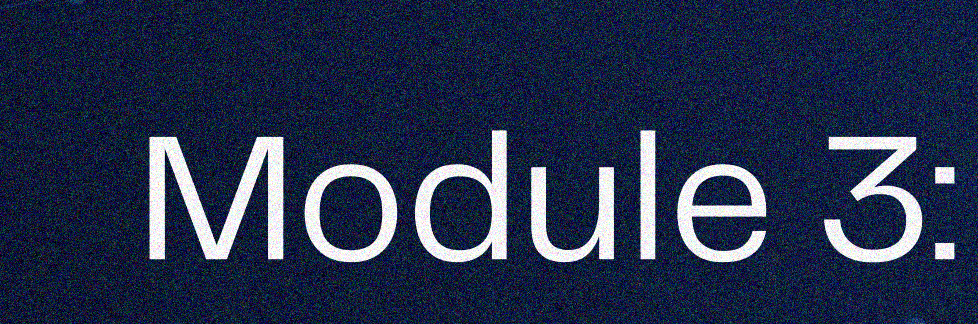

Tesseract : Module 3:
EasyOCR   : Module 3: (conf: 0.87)
PaddleOCR : Module 3: (conf: 0.97)
--------------------------------------------------

--- Processing: Brighter ---
[2026/03/09 02:51:05] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.10234260559082031
[2026/03/09 02:51:05] ppocr DEBUG: cls num  : 1, elapsed : 0.011130332946777344
[2026/03/09 02:51:05] ppocr DEBUG: rec_res num  : 1, elapsed : 0.06960940361022949


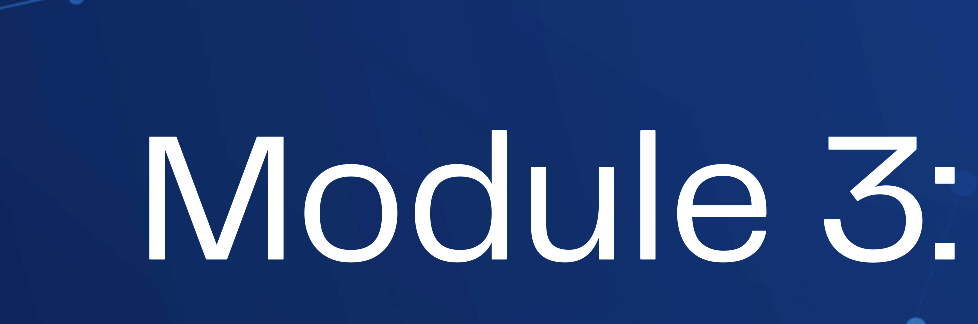

Tesseract : Module SS
EasyOCR   : Module 3: (conf: 0.84)
PaddleOCR : Module 3: (conf: 1.00)
--------------------------------------------------

--- Processing: Darker ---
[2026/03/09 02:51:10] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.09811043739318848
[2026/03/09 02:51:10] ppocr DEBUG: cls num  : 1, elapsed : 0.012314319610595703
[2026/03/09 02:51:10] ppocr DEBUG: rec_res num  : 1, elapsed : 0.07171511650085449


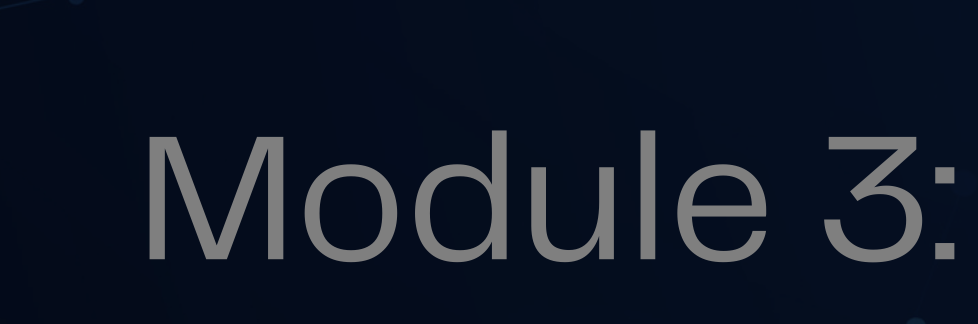

Tesseract : Module 3:
EasyOCR   : Module 3: (conf: 0.84)
PaddleOCR : Module 3z (conf: 0.98)
--------------------------------------------------

--- Processing: High Contrast ---
[2026/03/09 02:51:15] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.14000678062438965
[2026/03/09 02:51:15] ppocr DEBUG: cls num  : 1, elapsed : 0.021709203720092773
[2026/03/09 02:51:15] ppocr DEBUG: rec_res num  : 1, elapsed : 0.0981132984161377


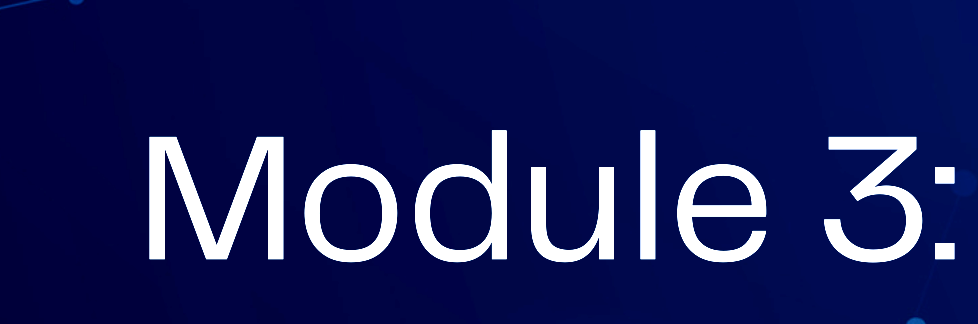

Tesseract : Module oS
EasyOCR   : Module 3: (conf: 0.83)
PaddleOCR : Module 3: (conf: 1.00)
--------------------------------------------------

--- Processing: Resized 50% ---
[2026/03/09 02:51:18] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.10380864143371582
[2026/03/09 02:51:18] ppocr DEBUG: cls num  : 1, elapsed : 0.012185096740722656
[2026/03/09 02:51:18] ppocr DEBUG: rec_res num  : 1, elapsed : 0.08779788017272949


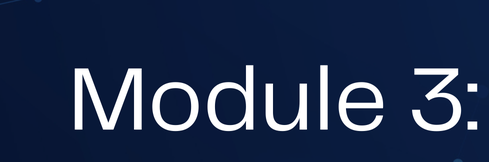

Tesseract : Module 3:
EasyOCR   : Module 3: (conf: 0.94)
PaddleOCR : Module 3: (conf: 0.94)
--------------------------------------------------

--- Processing: Inverted Colors ---
[2026/03/09 02:51:23] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.10805249214172363
[2026/03/09 02:51:23] ppocr DEBUG: cls num  : 1, elapsed : 0.022057056427001953
[2026/03/09 02:51:23] ppocr DEBUG: rec_res num  : 1, elapsed : 0.06682372093200684


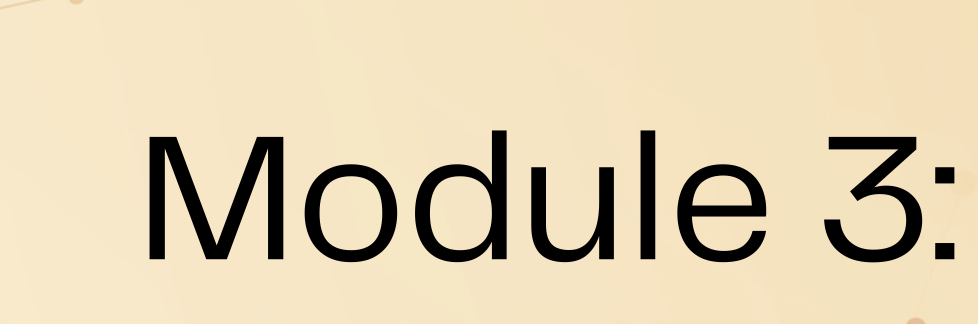

Tesseract : Module 3:
EasyOCR   : Module 3: (conf: 0.34)
PaddleOCR : Module 3: (conf: 1.00)
--------------------------------------------------

--- Processing: Perspective Warp ---
[2026/03/09 02:51:28] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.1505413055419922
[2026/03/09 02:51:28] ppocr DEBUG: cls num  : 1, elapsed : 0.01693868637084961
[2026/03/09 02:51:28] ppocr DEBUG: rec_res num  : 1, elapsed : 0.10014700889587402


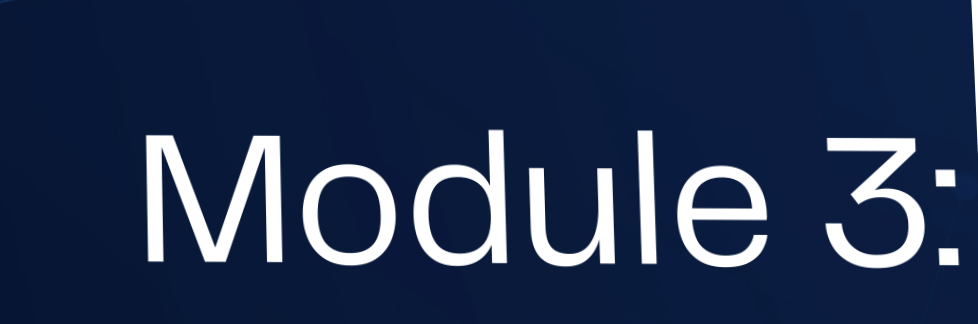

Tesseract : Module a
EasyOCR   : Module 3: (conf: 1.00)
PaddleOCR : Module 3: (conf: 1.00)
--------------------------------------------------


In [9]:
results = []

for idx, (img, desc) in enumerate(variations):
    print(f"\n--- Processing: {desc} ---")

    # Convert PIL to numpy for EasyOCR and PaddleOCR
    img_np = np.array(img)

    # ----- Tesseract -----
    try:
        tess_text = pytesseract.image_to_string(img).strip().replace('\n', ' ')
        if tess_text == "":
            tess_text = "[No text]"
    except Exception as e:
        tess_text = f"[Error: {e}]"

    # ----- EasyOCR -----
    try:
        easy_result = easy_reader.readtext(img_np)
        if easy_result:
            easy_text = ' '.join([item[1] for item in easy_result])
            easy_conf = np.mean([item[2] for item in easy_result])  # average confidence
        else:
            easy_text = "[No text]"
            easy_conf = 0.0
    except Exception as e:
        easy_text = f"[Error: {e}]"
        easy_conf = 0.0

    # ----- PaddleOCR -----
    try:
        paddle_result = paddle_ocr.ocr(img_np, cls=True)
        if paddle_result and paddle_result[0]:
            paddle_text = ' '.join([item[1][0] for item in paddle_result[0]])
            paddle_conf = np.mean([item[1][1] for item in paddle_result[0]])  # average confidence
        else:
            paddle_text = "[No text]"
            paddle_conf = 0.0
    except Exception as e:
        paddle_text = f"[Error: {e}]"
        paddle_conf = 0.0

    # Store
    results.append({
        'variation': desc,
        'tesseract': tess_text,
        'easyocr': easy_text,
        'paddleocr': paddle_text,
        'easy_conf': easy_conf,
        'paddle_conf': paddle_conf
    })

    # Show image and extracted texts (optional)
    display(img)
    print(f"Tesseract : {tess_text}")
    print(f"EasyOCR   : {easy_text} (conf: {easy_conf:.2f})")
    print(f"PaddleOCR : {paddle_text} (conf: {paddle_conf:.2f})")
    print("-" * 50)

# Compare and Compute Accuracy

In [10]:
# Normalize function to clean text for comparison
def normalize(text):
    # Remove extra spaces, convert to lower case
    return re.sub(r'\s+', ' ', text.strip().lower())

ground_truth_norm = normalize(ground_truth)

correct_counts = {'tesseract': 0, 'easyocr': 0, 'paddleocr': 0}
total = len(variations)

for res in results:
    for lib in ['tesseract', 'easyocr', 'paddleocr']:
        extracted = res[lib]
        if extracted.startswith("[Error") or extracted == "[No text]":
            continue
        if normalize(extracted) == ground_truth_norm:
            correct_counts[lib] += 1

# Accuracy percentages
accuracy = {lib: (correct_counts[lib] / total) * 100 for lib in correct_counts}

# Also compute average confidence for correct predictions (EasyOCR & PaddleOCR)
easy_conf_correct = [res['easy_conf'] for res in results if normalize(res['easyocr']) == ground_truth_norm]
paddle_conf_correct = [res['paddle_conf'] for res in results if normalize(res['paddleocr']) == ground_truth_norm]

avg_easy_conf = np.mean(easy_conf_correct) if easy_conf_correct else 0
avg_paddle_conf = np.mean(paddle_conf_correct) if paddle_conf_correct else 0

# Display Summary

In [19]:
print("\n" + "="*70)
print("SUMMARY: OCR COMPARISON")
print("="*70)
print(f"Ground truth: '{ground_truth}'")
print(f"Total variations: {total}\n")

print(f"{'Library':<15} {'Correct':<10} {'Accuracy':<10} {'Avg Confidence (correct)':<25}")
print("-" * 60)
print(f"{'Tesseract':<15} {correct_counts['tesseract']:<10} {accuracy['tesseract']:.1f}% {'N/A':>9}")
print(f"{'EasyOCR':<15} {correct_counts['easyocr']:<10} {accuracy['easyocr']:.1f}% {avg_easy_conf:10.2f}")
print(f"{'PaddleOCR':<15} {correct_counts['paddleocr']:<10} {accuracy['paddleocr']:.1f}% {avg_paddle_conf:10.2f}")

# Find best library
best_lib = max(accuracy, key=accuracy.get)
best_accuracy = accuracy[best_lib]
print("\n" + "="*70)
print(f"🏆 BEST LIBRARY for your image: **{best_lib}** with {best_accuracy:.1f}% accuracy")
print("="*70)


SUMMARY: OCR COMPARISON
Ground truth: 'Module 3:'
Total variations: 13

Library         Correct    Accuracy   Avg Confidence (correct) 
------------------------------------------------------------
Tesseract       6          46.2%       N/A
EasyOCR         10         76.9%       0.82
PaddleOCR       12         92.3%       0.99

🏆 BEST LIBRARY for your image: **paddleocr** with 92.3% accuracy


# Bar Chart

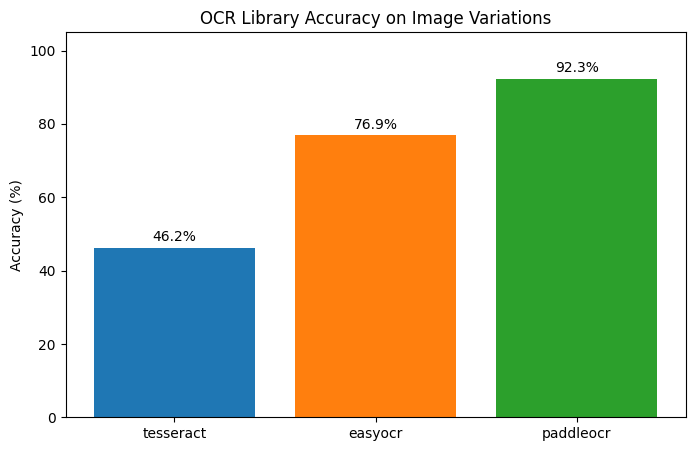

In [20]:
import matplotlib.pyplot as plt

libraries = list(accuracy.keys())
acc_values = list(accuracy.values())

plt.figure(figsize=(8,5))
bars = plt.bar(libraries, acc_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Accuracy (%)')
plt.title('OCR Library Accuracy on Image Variations')
plt.ylim(0, 105)
for bar, acc in zip(bars, acc_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc:.1f}%', ha='center', va='bottom')
plt.show()